# Synthetic Covariate Shift SCRC Experiment

**Research question**: Under *pure* covariate shift, does GNN-DRE's higher ESS (~31%) translate
into honest FNR ≤ α guarantees on the target, while LR-DRE fails due to low ESS?

## Setup
CheXpert is randomly split 60/40 into **Source** (clean) and **Target** (Gaussian-blurred):
- **No label shift**: P(Y) identical by construction (same dataset, random split)
- **No concept shift**: P(Y|X) preserved (disease concepts unchanged by blur)
- **Pure covariate shift**: P(X) differs due to image degradation

Under these conditions, conformal theory predicts GNN Test FNR ≈ α when ESS is high.

## Architecture
```
CheXpert (N=64,534)
├── Source (60%) — CLEAN pre-extracted features
│   ├── Train  (75% of Source)  → fit LR + GNN
│   └── Cal    (25% of Source)  → SCRC calibration
└── Target (40%) — PERTURBED features (re-extracted with Gaussian blur)
    ├── DRE Pool (50% of Target) → fit DRE domain classifier
    └── Test     (50% of Target) → SCRC evaluation
```

## Three SCRC arms
| Arm | Probs | DRE | Expected ESS |
|-----|-------|-----|--------------|
| LR-DRE (nc)  | LR predict_proba | 1024-dim PCA-4, no clip | ~1% |
| LR-DRE (c)   | LR predict_proba | 1024-dim PCA-4, clip=20 | ~6% |
| GNN-DRE (c)  | GNN sigmoid      | 7-dim prob space, clip=20 | ~31% |

In [1]:
from pathlib import Path
import torch

ROOT = Path('/Users/amo/programData/wcp-l2d')

# ============================================================
# USER CONFIGURATION — set CHEXPERT_IMGPATH before running
# Goldilocks tuning (Cell 5) and feature extraction (Cell 6)
# ============================================================
CHEXPERT_IMGPATH = '/Users/amo/programData/wcp-l2d/data/chexpert'
# ============================================================

SIGMA    = 3.0    # Gaussian blur sigma (tune in Cell 5 or set manually)
SEED     = 42
BETA     = 0.15   # Stage 1 deferral budget
ALPHA    = 0.10   # Stage 2 FNR target
K        = 7
N_WARMUP = 500    # Unlabeled target samples for SCRC-T WU threshold estimation
DEVICE   = 'mps' if torch.backends.mps.is_available() else 'cpu'

FEAT_DIR        = ROOT / 'data' / 'features'
PERTURBED_CACHE = FEAT_DIR / f'chexpert_target_perturbed_sigma{SIGMA:.1f}_features.npz'

print(f'Device:           {DEVICE}')
print(f'SIGMA:            {SIGMA}')
print(f'BETA / ALPHA:     {BETA} / {ALPHA}')
print(f'N_WARMUP:         {N_WARMUP}')
print(f'PERTURBED_CACHE:  {PERTURBED_CACHE}')
if CHEXPERT_IMGPATH is None:
    print('\nNOTE: CHEXPERT_IMGPATH is None.')
    print('  Cells 5-6 will be skipped if perturbed cache does not exist.')
    print(f'  Cache exists: {PERTURBED_CACHE.exists()}')


Device:           mps
SIGMA:            3.0
BETA / ALPHA:     0.15 / 0.1
N_WARMUP:         500
PERTURBED_CACHE:  /Users/amo/programData/wcp-l2d/data/features/chexpert_target_perturbed_sigma3.0_features.npz


In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from torchvision import transforms
from torch.utils.data import Subset as TorchSubset

if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from wcp_l2d.dre import AdaptiveDRE
from wcp_l2d.features import ExtractedFeatures, load_model, extract_features
from wcp_l2d.data import load_and_align_dataset, apply_xrv_transforms, make_dataloader
from wcp_l2d.gnn import build_adjacency_matrix, train_gnn
from wcp_l2d.pathologies import COMMON_PATHOLOGIES
from wcp_l2d.scrc import (
    multilabel_entropy, select_for_deferral, calibrate_per_pathology_crc_fnr
)

np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 100, 'figure.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
})

print(f'Pathologies: {COMMON_PATHOLOGIES}')


class GaussianBlurNP:
    """Gaussian blur on numpy (C, H, W) arrays. Compatible with xrv transforms."""
    def __init__(self, sigma):
        self.sigma = sigma
    def __call__(self, img):
        return gaussian_filter(img, sigma=[0, self.sigma, self.sigma])

Pathologies: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Pneumonia', 'Pneumothorax']


## 1. Load Pre-extracted Features + 60/40 Index Split

- **Source** (60%): clean, pre-extracted features — used as-is
- **Target** (40%): same CheXpert images but will be re-extracted with Gaussian blur
- Labels are identical for both halves → **no label shift by construction**

In [3]:
chex = ExtractedFeatures.load(FEAT_DIR / 'chexpert_densenet121-res224-chex_features.npz')
print(f'CheXpert: {chex.features.shape}  labels: {chex.labels.shape}')

rng        = np.random.RandomState(SEED)
all_pos    = rng.permutation(len(chex.features))
n_source   = int(0.60 * len(chex.features))
source_pos = all_pos[:n_source]   # positions in .npz array → clean features
target_pos = all_pos[n_source:]   # positions in .npz array → will be perturbed

orig_target_idx = chex.indices[target_pos]   # original CheXpert dataset indices

X_source_raw = chex.features[source_pos]   # (n_source, 1024) — clean
Y_source     = chex.labels[source_pos]     # (n_source, 7)
Y_target     = chex.labels[target_pos]     # (n_target, 7) — same labels, NO label shift

print(f'Source: {X_source_raw.shape}  (60% clean pre-extracted)')
print(f'Target: {len(Y_target):,} samples  (40% — will use perturbed features)')
print(f'\nLabel shift verification (source vs target prevalence):')
print(f'{"Pathology":15s} | {"Source":8s} | {"Target":8s} | {"Delta":8s}')
print('-' * 50)
for k, name in enumerate(COMMON_PATHOLOGIES):
    sp = np.nanmean(Y_source[:, k])
    tp = np.nanmean(Y_target[:, k])
    print(f'{name:15s} | {sp:8.4f} | {tp:8.4f} | {tp-sp:+8.4f}')
print('\nExpected: all Delta ≈ 0 (same dataset, random split)')

CheXpert: (64534, 1024)  labels: (64534, 7)
Source: (38720, 1024)  (60% clean pre-extracted)
Target: 25,814 samples  (40% — will use perturbed features)

Label shift verification (source vs target prevalence):
Pathology       | Source   | Target   | Delta   
--------------------------------------------------
Atelectasis     |   0.4706 |   0.4688 |  -0.0018
Cardiomegaly    |   0.3369 |   0.3413 |  +0.0044
Consolidation   |   0.1904 |   0.1975 |  +0.0070
Edema           |   0.4203 |   0.4196 |  -0.0007
Effusion        |   0.4658 |   0.4703 |  +0.0046
Pneumonia       |   0.1630 |   0.1559 |  -0.0071
Pneumothorax    |   0.1151 |   0.1186 |  +0.0035

Expected: all Delta ≈ 0 (same dataset, random split)


## 2. Goldilocks Sigma Tuning (optional — requires CHEXPERT_IMGPATH)

Test σ ∈ {1.0, 2.0, 3.0, 5.0, 7.0} on a small subset (~500 images).

**Goldilocks criteria**:
- Domain AUC ∈ [0.90, 0.98]: shift is detectable but not extreme
- Mean AUC drop ∈ [0.05, 0.10]: meaningful but not catastrophic degradation

Skip this cell and use `SIGMA=3.0` if images are not available.

In [4]:
# Goldilocks tuning skipped — SIGMA=3.0 pre-chosen.
# To run full tuning, replace this cell with the commented-out version in the source notebook.
print(f"Goldilocks tuning skipped.  Using pre-set SIGMA={SIGMA}.")


Goldilocks tuning skipped.  Using pre-set SIGMA=3.0.


## 3. Extract Perturbed Target Features (cached)

Re-extract features for the 40% target subset with Gaussian blur applied.
Cached to `PERTURBED_CACHE` so this only runs once per sigma.

In [5]:
if PERTURBED_CACHE.exists():
    print(f'Loading cached perturbed features: {PERTURBED_CACHE}')
    _cache       = np.load(PERTURBED_CACHE, allow_pickle=True)
    X_target_raw = _cache['features']
    assert _cache['labels'].shape == Y_target.shape, 'Label shape mismatch in cache!'
    print(f'Loaded X_target_raw: {X_target_raw.shape}')
    print('Label shape check: PASS')
else:
    if CHEXPERT_IMGPATH is None:
        raise RuntimeError(
            f'Cache {PERTURBED_CACHE} not found and CHEXPERT_IMGPATH is None.\n'
            'Set CHEXPERT_IMGPATH in Cell 1, run Goldilocks tuning, then retry.'
        )
    print(f'Extracting perturbed features for {len(orig_target_idx):,} images '
          f'(sigma={SIGMA}) ...')
    chex_ds = load_and_align_dataset('chexpert', CHEXPERT_IMGPATH)
    apply_xrv_transforms(chex_ds)
    chex_ds.transform = transforms.Compose([chex_ds.transform, GaussianBlurNP(SIGMA)])

    tgt_subset = TorchSubset(chex_ds, orig_target_idx.tolist())
    loader     = make_dataloader(tgt_subset, batch_size=128, num_workers=4)
    model_full = load_model(weights='densenet121-res224-chex', device=DEVICE)
    X_target_raw, _, _ = extract_features(model_full, loader, DEVICE)

    np.savez_compressed(
        PERTURBED_CACHE,
        features=X_target_raw,
        labels=Y_target,
        indices=orig_target_idx,
        pathologies=np.array(COMMON_PATHOLOGIES),
        dataset_name=np.array('chexpert_perturbed'),
        model_weights=np.array('densenet121-res224-chex'),
    )
    print(f'Saved to {PERTURBED_CACHE}')

print(f'X_target_raw shape: {X_target_raw.shape}')

Loading cached perturbed features: /Users/amo/programData/wcp-l2d/data/features/chexpert_target_perturbed_sigma3.0_features.npz


Loaded X_target_raw: (25814, 1024)
Label shape check: PASS
X_target_raw shape: (25814, 1024)


## 4. Goldilocks Verification on Full Dataset

In [6]:
# Domain AUC (PCA-4) on subsampled source vs full target
_rng_v      = np.random.RandomState(SEED)
_n_sample   = min(5000, len(X_source_raw), len(X_target_raw))
_src_idx    = _rng_v.choice(len(X_source_raw), _n_sample, replace=False)
_tgt_idx    = _rng_v.choice(len(X_target_raw), _n_sample, replace=False)
_X_dom      = np.vstack([X_source_raw[_src_idx], X_target_raw[_tgt_idx]])
_y_dom      = np.array([0] * _n_sample + [1] * _n_sample)
_sc_v       = StandardScaler().fit(_X_dom)
_pca_v      = PCA(n_components=4, random_state=SEED).fit(_sc_v.transform(_X_dom))
_X_pca      = _pca_v.transform(_sc_v.transform(_X_dom))
_lr_v       = LogisticRegression(solver='lbfgs', max_iter=500, random_state=SEED)
_lr_v.fit(_X_pca, _y_dom)
full_domain_auc = roc_auc_score(_y_dom, _lr_v.predict_proba(_X_pca)[:, 1])

print(f'Full-dataset Domain AUC (PCA-4, n={_n_sample}): {full_domain_auc:.4f}')
status = 'PASS' if 0.90 <= full_domain_auc <= 0.98 else 'OUTSIDE range — consider adjusting SIGMA'
print(f'Goldilocks target [0.90, 0.98]: {status}')

Full-dataset Domain AUC (PCA-4, n=5000): 0.9984
Goldilocks target [0.90, 0.98]: OUTSIDE range — consider adjusting SIGMA


## 5. Sub-splits + StandardScaler

```
Source (60%)
  └── Train (75%) + Cal (25%)
Target (40%)
  └── DRE Pool (50%) + Test (50%)
```

StandardScaler fit on SOURCE train, applied to all sets.

In [7]:
n_tr        = int(0.75 * n_source)
X_train_raw = X_source_raw[:n_tr]
Y_train     = Y_source[:n_tr]
X_cal_raw   = X_source_raw[n_tr:]
Y_cal       = Y_source[n_tr:]

n_pool      = len(X_target_raw) // 2
X_pool_raw  = X_target_raw[:n_pool]
X_test_raw  = X_target_raw[n_pool:]
Y_pool_tgt  = Y_target[:n_pool]
Y_test      = Y_target[n_pool:]

scaler  = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_cal   = scaler.transform(X_cal_raw)
X_pool  = scaler.transform(X_pool_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train:  {X_train.shape}  (source clean)')
print(f'Cal:    {X_cal.shape}    (source clean)')
print(f'Pool:   {X_pool.shape}   (target perturbed, DRE fitting)')
print(f'Test:   {X_test.shape}   (target perturbed, SCRC evaluation)')
print(f'\nPure covariate shift check (prevalences should match):')
print(f'{"Pathology":15s} | {"Cal (src)":10s} | {"Test (tgt)":10s}')
print('-' * 42)
for k, name in enumerate(COMMON_PATHOLOGIES):
    print(f'{name:15s} | {np.nanmean(Y_cal[:, k]):10.4f} | {np.nanmean(Y_test[:, k]):10.4f}')

Train:  (29040, 1024)  (source clean)
Cal:    (9680, 1024)    (source clean)
Pool:   (12907, 1024)   (target perturbed, DRE fitting)
Test:   (12907, 1024)   (target perturbed, SCRC evaluation)

Pure covariate shift check (prevalences should match):
Pathology       | Cal (src)  | Test (tgt)
------------------------------------------
Atelectasis     |     0.4773 |     0.4758
Cardiomegaly    |     0.3409 |     0.3489
Consolidation   |     0.1896 |     0.1998
Edema           |     0.4326 |     0.4271
Effusion        |     0.4664 |     0.4812
Pneumonia       |     0.1643 |     0.1568
Pneumothorax    |     0.1155 |     0.1192


In [8]:
# Label distribution per split: n_pos / n_neg / n_nan and their percentages
splits_info = [
    ('Train',    Y_train),
    ('Cal',      Y_cal),
    ('Pool',     Y_pool_tgt),
    ('Test',     Y_test),
]

for split_name, Y in splits_info:
    n = len(Y)
    print(f'{split_name}  (n={n:,}):')
    print(f'  {"Pathology":15s} | {"Pos n (%)":>14s} | {"Neg n (%)":>14s} | {"NaN n (%)":>14s}')
    print('  ' + '-' * 65)
    for k, name in enumerate(COMMON_PATHOLOGIES):
        n_pos = int((Y[:, k] == 1).sum())
        n_neg = int((Y[:, k] == 0).sum())
        n_nan = int(np.isnan(Y[:, k]).sum())
        print(
            f'  {name:15s} | {n_pos:5d} ({n_pos/n*100:5.1f}%) | '
            f'{n_neg:5d} ({n_neg/n*100:5.1f}%) | '
            f'{n_nan:5d} ({n_nan/n*100:5.1f}%)'
        )
    print()

Train  (n=29,040):
  Pathology       |      Pos n (%) |      Neg n (%) |      NaN n (%)
  -----------------------------------------------------------------
  Atelectasis     |  5719 ( 19.7%) |  6491 ( 22.4%) | 16830 ( 58.0%)
  Cardiomegaly    |  4069 ( 14.0%) |  8054 ( 27.7%) | 16917 ( 58.3%)
  Consolidation   |  2424 (  8.3%) | 10286 ( 35.4%) | 16330 ( 56.2%)
  Edema           |  6634 ( 22.8%) |  9307 ( 32.0%) | 13099 ( 45.1%)
  Effusion        |  9279 ( 32.0%) | 10651 ( 36.7%) |  9110 ( 31.4%)
  Pneumonia       |  1304 (  4.5%) |  6715 ( 23.1%) | 21021 ( 72.4%)
  Pneumothorax    |  1911 (  6.6%) | 14706 ( 50.6%) | 12423 ( 42.8%)

Cal  (n=9,680):
  Pathology       |      Pos n (%) |      Neg n (%) |      NaN n (%)
  -----------------------------------------------------------------
  Atelectasis     |  1916 ( 19.8%) |  2098 ( 21.7%) |  5666 ( 58.5%)
  Cardiomegaly    |  1367 ( 14.1%) |  2643 ( 27.3%) |  5670 ( 58.6%)
  Consolidation   |   782 (  8.1%) |  3343 ( 34.5%) |  5555 ( 57.4%)


## 6. Binary LR Classifiers (per-pathology, Source train)

Used for:
1. LR SCRC arm probabilities (`predict_proba`)
2. GNN residual logit initialisation (`decision_function`)

In [9]:
lrs = []
for k, name in enumerate(COMMON_PATHOLOGIES):
    valid = ~np.isnan(Y_train[:, k])
    if valid.sum() < 10 or len(np.unique(Y_train[valid, k])) < 2:
        lrs.append(None)
        continue
    lr = LogisticRegression(solver='lbfgs', max_iter=500, random_state=SEED)
    lr.fit(X_train[valid], Y_train[valid, k].astype(int))
    lrs.append(lr)


def get_logits_lr(lrs_, X_s):
    """[N, K] decision_function for GNN residual init."""
    out = np.zeros((len(X_s), K), dtype=np.float32)
    for k, lr in enumerate(lrs_):
        if lr is not None:
            out[:, k] = lr.decision_function(X_s)
    return out


def get_proba_lr(lrs_, X_s):
    """[N, K] predict_proba[:, 1] for LR SCRC arm."""
    out = np.zeros((len(X_s), K), dtype=np.float32)
    for k, lr in enumerate(lrs_):
        if lr is not None:
            out[:, k] = lr.predict_proba(X_s)[:, 1]
    return out


init_tr   = get_logits_lr(lrs, X_train)
init_cal  = get_logits_lr(lrs, X_cal)
init_pool = get_logits_lr(lrs, X_pool)
init_test = get_logits_lr(lrs, X_test)

p_cal_lr  = get_proba_lr(lrs, X_cal)     # LR probs on SOURCE cal (for calibration)
p_test_lr = get_proba_lr(lrs, X_test)    # LR probs on TARGET test (for evaluation)

print('LR classifiers trained.')
print(f'p_cal_lr:  {p_cal_lr.shape}')
print(f'p_test_lr: {p_test_lr.shape}')

LR classifiers trained.
p_cal_lr:  (9680, 7)
p_test_lr: (12907, 7)


## 7. Label Co-occurrence Adjacency + GNN Training

In [10]:
A = build_adjacency_matrix(Y_train, tau=0.10)
assert torch.allclose(A.sum(dim=1), torch.ones(K), atol=1e-5), 'Row sums must equal 1'
print(f'Adjacency: {A.shape}  non-zero off-diag: {int((A > 0).sum()) - K}/{K*(K-1)}')

print(f'\nTraining LabelGCN on {DEVICE} (50 epochs) ...')
gnn, history = train_gnn(
    features_train=X_train,
    labels_train=Y_train,
    features_val=X_cal,
    labels_val=Y_cal,
    adjacency=A,
    init_logits_train=init_tr,
    init_logits_val=init_cal,
    epochs=50,
    save_best=True,
    batch_size=512,
    lr=1e-3,
    weight_decay=1e-4,
    device=DEVICE,
    verbose=False,
)
best_ep = history['best_epoch'][0]
print(f'Best val AUC: {max(history["val_auc"]):.4f}  at epoch {best_ep}/50')

Adjacency: torch.Size([7, 7])  non-zero off-diag: 34/42

Training LabelGCN on mps (50 epochs) ...


Best val AUC: 0.8340  at epoch 38/50


## 8. GNN Probability Extraction

In [11]:
def get_probs_gnn(model, X_s, init_np, batch_size=2048):
    """Batched GNN forward pass → sigmoid [N, K]."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for start in range(0, len(X_s), batch_size):
            end  = min(start + batch_size, len(X_s))
            Xt   = torch.tensor(X_s[start:end], dtype=torch.float32)
            it   = torch.tensor(init_np[start:end], dtype=torch.float32)
            logi = model(Xt, it).numpy()
            all_probs.append(1.0 / (1.0 + np.exp(-logi)))
    return np.vstack(all_probs)


p_cal_gnn  = get_probs_gnn(gnn, X_cal,  init_cal)
p_pool_gnn = get_probs_gnn(gnn, X_pool, init_pool)
p_test_gnn = get_probs_gnn(gnn, X_test, init_test)

print(f'p_cal_gnn:  {p_cal_gnn.shape}')
print(f'p_pool_gnn: {p_pool_gnn.shape}')
print(f'p_test_gnn: {p_test_gnn.shape}')

# Per-pathology AUC on TARGET test: LR vs GNN
print(f'\nTarget test AUC (LR vs GNN):')
print(f'{"Pathology":15s} | {"LR AUC":8s} | {"GNN AUC":8s} | {"ΔAUC":8s}')
print('-' * 52)
for k, name in enumerate(COMMON_PATHOLOGIES):
    valid = ~np.isnan(Y_test[:, k])
    if valid.sum() < 2 or len(np.unique(Y_test[valid, k])) < 2:
        print(f'{name:15s} | {"N/A":8s} | {"N/A":8s}')
        continue
    auc_lr  = roc_auc_score(Y_test[valid, k], p_test_lr[valid, k])
    auc_gnn = roc_auc_score(Y_test[valid, k], p_test_gnn[valid, k])
    print(f'{name:15s} | {auc_lr:8.4f} | {auc_gnn:8.4f} | {auc_gnn-auc_lr:+8.4f}')

p_cal_gnn:  (9680, 7)
p_pool_gnn: (12907, 7)
p_test_gnn: (12907, 7)

Target test AUC (LR vs GNN):
Pathology       | LR AUC   | GNN AUC  | ΔAUC    
----------------------------------------------------
Atelectasis     |   0.7409 |   0.7663 |  +0.0254
Cardiomegaly    |   0.8382 |   0.8527 |  +0.0146
Consolidation   |   0.7845 |   0.8204 |  +0.0359
Edema           |   0.7791 |   0.8131 |  +0.0340
Effusion        |   0.8160 |   0.8388 |  +0.0228
Pneumonia       |   0.6902 |   0.7402 |  +0.0500
Pneumothorax    |   0.5999 |   0.6435 |  +0.0435


In [12]:
import copy
import torch.nn as nn

# ============================================================
# 8b. Two-Layer MLP Baseline (Matched-Parameter Comparison)
# Two-layer MLP: Linear(1024,1316) + ReLU + Dropout(0.3) + Linear(1316,7)
# ~1.36M params, matching LabelGCN.  No graph structure, no init_logits residual.
# ============================================================

class MLP(nn.Module):
    def __init__(self, feat_dim=1024, hidden_dim=1316, K=7, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, K),
        )
    def forward(self, x):
        return self.net(x)


def train_mlp(features_train, labels_train, features_val, labels_val,
              feat_dim=1024, hidden_dim=1316, n_labels=7, dropout=0.3,
              epochs=50, batch_size=512, lr=1e-3, weight_decay=1e-4,
              device='cpu', seed=42, verbose=False, save_best=True):
    """Train two-layer MLP with NaN-masked BCE loss. Mirrors train_gnn API."""
    torch.manual_seed(seed)
    model = MLP(feat_dim=feat_dim, hidden_dim=hidden_dim, K=n_labels,
                dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                  weight_decay=weight_decay)
    bce = nn.BCEWithLogitsLoss(reduction='none')

    Xtr = torch.tensor(features_train, dtype=torch.float32).to(device)
    Ytr = torch.tensor(
        np.where(np.isnan(labels_train), -1.0, labels_train),
        dtype=torch.float32).to(device)
    Xval = torch.tensor(features_val, dtype=torch.float32).to(device)

    N = Xtr.shape[0]
    history = {'train_loss': [], 'val_auc': [], 'best_epoch': [1]}
    best_val_auc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(N, device=device)
        epoch_loss, n_batches = 0.0, 0
        for start in range(0, N, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = Xtr[idx], Ytr[idx]
            logits = model(xb)
            valid_mask = (yb >= 0).float()
            yb_safe = yb.clamp(min=0)
            loss_raw = bce(logits, yb_safe)
            valid_count = valid_mask.sum().clamp(min=1)
            loss = (loss_raw * valid_mask).sum() / valid_count
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        history['train_loss'].append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            val_logits = model(Xval).cpu().numpy()
        val_probs = 1.0 / (1.0 + np.exp(-val_logits))
        aucs = []
        for k_ in range(n_labels):
            valid = ~np.isnan(labels_val[:, k_])
            if valid.sum() >= 10 and len(np.unique(labels_val[valid, k_])) >= 2:
                aucs.append(roc_auc_score(labels_val[valid, k_],
                                          val_probs[valid, k_]))
        mean_auc = float(np.mean(aucs)) if aucs else 0.0
        history['val_auc'].append(mean_auc)

        if save_best and mean_auc > best_val_auc:
            best_val_auc = mean_auc
            best_state = copy.deepcopy(model.state_dict())
            history['best_epoch'] = [epoch]
        if verbose:
            print(f'  Epoch {epoch:3d}/{epochs}  '
                  f'loss={epoch_loss/n_batches:.4f}  val_auc={mean_auc:.4f}')

    if save_best and best_state is not None:
        model.load_state_dict(best_state)
    return model.cpu(), history


def get_probs_mlp(model, X_s, batch_size=2048):
    """Batched MLP forward pass → sigmoid [N, K]."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for start in range(0, len(X_s), batch_size):
            end = min(start + batch_size, len(X_s))
            Xt = torch.tensor(X_s[start:end], dtype=torch.float32)
            logi = model(Xt).numpy()
            all_probs.append(1.0 / (1.0 + np.exp(-logi)))
    return np.vstack(all_probs)


n_params_mlp = sum(p.numel() for p in MLP().parameters())
print(f'MLP param count: {n_params_mlp:,}  (LabelGCN: ~1,357,883)')

print(f'\nTraining MLP on {DEVICE} (50 epochs, save_best=True) ...')
mlp, hist_mlp = train_mlp(
    features_train=X_train, labels_train=Y_train,
    features_val=X_cal, labels_val=Y_cal,
    epochs=50, save_best=True,
    batch_size=512, lr=1e-3, weight_decay=1e-4,
    device=DEVICE, seed=SEED, verbose=False,
)
best_ep_mlp = hist_mlp['best_epoch'][0]
print(f'Best val AUC: {max(hist_mlp["val_auc"]):.4f}  at epoch {best_ep_mlp}/50')

p_cal_mlp  = get_probs_mlp(mlp, X_cal)
p_pool_mlp = get_probs_mlp(mlp, X_pool)
p_test_mlp = get_probs_mlp(mlp, X_test)

print(f'\np_cal_mlp:  {p_cal_mlp.shape}')
print(f'p_pool_mlp: {p_pool_mlp.shape}')
print(f'p_test_mlp: {p_test_mlp.shape}')

# Target test AUC: LR vs GNN vs MLP
print(f'\nTarget test AUC (LR vs GNN vs MLP):')
print(f'{"Pathology":15s} | {"LR AUC":8s} | {"GNN AUC":8s} | {"MLP AUC":8s} | {"MLP-GNN Δ":9s}')
print('-' * 68)
for k, name in enumerate(COMMON_PATHOLOGIES):
    valid = ~np.isnan(Y_test[:, k])
    if valid.sum() < 2 or len(np.unique(Y_test[valid, k])) < 2:
        print(f'{name:15s} | {"N/A":8s} | {"N/A":8s} | {"N/A":8s}')
        continue
    auc_lr  = roc_auc_score(Y_test[valid, k], p_test_lr[valid, k])
    auc_gnn = roc_auc_score(Y_test[valid, k], p_test_gnn[valid, k])
    auc_mlp_k = roc_auc_score(Y_test[valid, k], p_test_mlp[valid, k])
    print(f'{name:15s} | {auc_lr:8.4f} | {auc_gnn:8.4f} | {auc_mlp_k:8.4f} | {auc_mlp_k-auc_gnn:+9.4f}')


MLP param count: 1,358,119  (LabelGCN: ~1,357,883)

Training MLP on mps (50 epochs, save_best=True) ...


Best val AUC: 0.8351  at epoch 1/50

p_cal_mlp:  (9680, 7)
p_pool_mlp: (12907, 7)
p_test_mlp: (12907, 7)

Target test AUC (LR vs GNN vs MLP):
Pathology       | LR AUC   | GNN AUC  | MLP AUC  | MLP-GNN Δ
--------------------------------------------------------------------
Atelectasis     |   0.7409 |   0.7663 |   0.7733 |   +0.0070
Cardiomegaly    |   0.8382 |   0.8527 |   0.8489 |   -0.0039
Consolidation   |   0.7845 |   0.8204 |   0.8248 |   +0.0043
Edema           |   0.7791 |   0.8131 |   0.8200 |   +0.0069
Effusion        |   0.8160 |   0.8388 |   0.8455 |   +0.0067
Pneumonia       |   0.6902 |   0.7402 |   0.7246 |   -0.0156
Pneumothorax    |   0.5999 |   0.6435 |   0.6305 |   -0.0129


## 9. Density Ratio Estimation (three variants)

Source = SOURCE cal features  
Target = TARGET DRE pool features  

| Variant | Space | PCA | Clip | Expected ESS |
|---------|-------|-----|------|--------------|
| LR-DRE (nc) | 1024-dim raw | PCA-4 | None | ~1% |
| LR-DRE (c)  | 1024-dim raw | PCA-4 | 20.0 | ~6% |
| GNN-DRE (c) | 7-dim probs  | None  | 20.0 | ~31% |

In [13]:
# 9a — LR-DRE no clip
dre_lr_nc = AdaptiveDRE(n_components=4, weight_clip=None, random_state=SEED)
dre_lr_nc.fit(source_features=X_cal_raw, target_features=X_pool_raw)
w_cal_lr_nc  = dre_lr_nc.compute_weights(X_cal_raw)
w_test_lr_nc = dre_lr_nc.compute_weights(X_test_raw)
diag_lr_nc   = dre_lr_nc.diagnostics(X_cal_raw)
print(f'LR-DRE (nc): domain_AUC={diag_lr_nc.domain_auc:.4f}, '
      f'ESS%={diag_lr_nc.ess_fraction*100:.2f}%, w_max={diag_lr_nc.weight_max:.1f}')

LR-DRE (nc): domain_AUC=0.9981, ESS%=0.29%, w_max=397.2


In [14]:
# 9b — LR-DRE clip=20
dre_lr = AdaptiveDRE(n_components=4, weight_clip=20.0, random_state=SEED)
dre_lr.fit(source_features=X_cal_raw, target_features=X_pool_raw)
w_cal_lr  = dre_lr.compute_weights(X_cal_raw)
w_test_lr = dre_lr.compute_weights(X_test_raw)
diag_lr   = dre_lr.diagnostics(X_cal_raw)
print(f'LR-DRE (c):  domain_AUC={diag_lr.domain_auc:.4f}, '
      f'ESS%={diag_lr.ess_fraction*100:.2f}%, w_max={diag_lr.weight_max:.1f}')

LR-DRE (c):  domain_AUC=0.9981, ESS%=1.44%, w_max=20.0


In [15]:
# 9c — GNN-DRE clip=20 (7-dim probability space)
dre_gnn = AdaptiveDRE(n_components=None, weight_clip=20.0, random_state=SEED)
dre_gnn.fit(source_features=p_cal_gnn, target_features=p_pool_gnn)
w_cal_gnn  = dre_gnn.compute_weights(p_cal_gnn)
w_test_gnn = dre_gnn.compute_weights(p_test_gnn)
diag_gnn   = dre_gnn.diagnostics(p_cal_gnn)
print(f'GNN-DRE (c): domain_AUC={diag_gnn.domain_auc:.4f}, '
      f'ESS%={diag_gnn.ess_fraction*100:.2f}%, w_max={diag_gnn.weight_max:.1f}')

GNN-DRE (c): domain_AUC=0.8643, ESS%=16.89%, w_max=20.0


In [16]:
# 9d — MLP-DRE clip=20 (7-dim MLP probability space, no graph structure)
dre_mlp = AdaptiveDRE(n_components=None, weight_clip=20.0, random_state=SEED)
dre_mlp.fit(source_features=p_cal_mlp, target_features=p_pool_mlp)
w_cal_mlp  = dre_mlp.compute_weights(p_cal_mlp)
w_test_mlp = dre_mlp.compute_weights(p_test_mlp)
diag_mlp   = dre_mlp.diagnostics(p_cal_mlp)
print(f'MLP-DRE (c): domain_AUC={diag_mlp.domain_auc:.4f}, '
      f'ESS%={diag_mlp.ess_fraction*100:.2f}%, w_max={diag_mlp.weight_max:.1f}')


MLP-DRE (c): domain_AUC=0.9362, ESS%=9.38%, w_max=20.0


In [17]:
dre_table = pd.DataFrame([
    {'Method': 'LR-DRE (no clip)', 'Domain AUC': round(diag_lr_nc.domain_auc, 4),
     'ESS%': round(diag_lr_nc.ess_fraction * 100, 2),
     'W_mean': round(float(w_cal_lr_nc.mean()), 3), 'W_max': round(float(w_cal_lr_nc.max()), 1)},
    {'Method': 'LR-DRE (clip=20)', 'Domain AUC': round(diag_lr.domain_auc, 4),
     'ESS%': round(diag_lr.ess_fraction * 100, 2),
     'W_mean': round(float(w_cal_lr.mean()), 3),    'W_max': round(float(w_cal_lr.max()), 1)},
    {'Method': 'GNN-DRE (clip=20)', 'Domain AUC': round(diag_gnn.domain_auc, 4),
     'ESS%': round(diag_gnn.ess_fraction * 100, 2),
     'W_mean': round(float(w_cal_gnn.mean()), 3),   'W_max': round(float(w_cal_gnn.max()), 1)},
    {'Method': 'MLP-DRE (clip=20)', 'Domain AUC': round(diag_mlp.domain_auc, 4),
     'ESS%': round(diag_mlp.ess_fraction * 100, 2),
     'W_mean': round(float(w_cal_mlp.mean()), 3),   'W_max': round(float(w_cal_mlp.max()), 1)},
])
print('DRE Weight Quality Comparison')
print(dre_table.to_string(index=False))
print('\nExpected: ESS%(GNN) >> ESS%(LR) under pure covariate shift')
print('MLP-DRE: 7-dim MLP probability space (no graph structure)')

DRE Weight Quality Comparison
           Method  Domain AUC  ESS%  W_mean  W_max
 LR-DRE (no clip)      0.9981  0.29   0.367  397.2
 LR-DRE (clip=20)      0.9981  1.44   0.168   20.0
GNN-DRE (clip=20)      0.8643 16.89   0.874   20.0
MLP-DRE (clip=20)      0.9362  9.38   0.753   20.0

Expected: ESS%(GNN) >> ESS%(LR) under pure covariate shift
MLP-DRE: 7-dim MLP probability space (no graph structure)


## 10. Stage 1 — SCRC-T WU Deferral (β = 0.15)

Derives an absolute entropy threshold τ_wu from N=500 unlabeled target (blurred) samples,
then applies the same τ_wu to both Cal and Test — restoring conditional exchangeability.

Stage 1 deferral mask is **shared** across all four SCRC arms (LR-nc, LR-c, GNN-c, MLP-c).
Cal deferral rate may exceed β because the clean-source GNN tends to produce higher
entropy on familiar source data than on shifted (blurred) target data.

In [18]:
entropy_cal = multilabel_entropy(p_cal_gnn)
entropy_tst = multilabel_entropy(p_test_gnn)

# SCRC-T WU: derive absolute threshold from N_WARMUP unlabeled target samples
rng_wu     = np.random.RandomState(SEED)
warmup_idx = rng_wu.choice(len(entropy_tst), size=N_WARMUP, replace=False)
entropy_wu = entropy_tst[warmup_idx]
tau_wu     = np.quantile(entropy_wu, 1.0 - BETA)

is_warmup  = np.zeros(len(entropy_tst), dtype=bool)
is_warmup[warmup_idx] = True

# Apply same absolute threshold to both sets
defer_cal  = entropy_cal > tau_wu
defer_tst  = entropy_tst > tau_wu

print(f'SCRC-T WU (τ_wu={tau_wu:.4f}, N_WARMUP={N_WARMUP}):')
print(f'  Cal:  {defer_cal.sum():,}/{len(defer_cal):,} deferred  ({defer_cal.mean()*100:.1f}%)')
print(f'  Test: {defer_tst.sum():,}/{len(defer_tst):,} deferred  ({defer_tst.mean()*100:.1f}%)')
print(f'  (Cal deferral may exceed β={BETA} due to entropy distribution direction)')
print(f'\nEntropy summary:')
print(f'  Cal entropy:  mean={entropy_cal.mean():.4f}  median={np.median(entropy_cal):.4f}')
print(f'  Test entropy: mean={entropy_tst.mean():.4f}  median={np.median(entropy_tst):.4f}')
print(f'  WU entropy:   mean={entropy_wu.mean():.4f}  median={np.median(entropy_wu):.4f}  (n={N_WARMUP})')


SCRC-T WU (τ_wu=3.8537, N_WARMUP=500):
  Cal:  2,837/9,680 deferred  (29.3%)
  Test: 2,160/12,907 deferred  (16.7%)
  (Cal deferral may exceed β=0.15 due to entropy distribution direction)

Entropy summary:
  Cal entropy:  mean=3.1315  median=3.4685
  Test entropy: mean=3.2158  median=3.4075
  WU entropy:   mean=3.2351  median=3.3680  (n=500)


## 11. Stage 2 — Per-pathology SCRC Calibration (3 arms)

For each arm, calibrate λ_k* = sup{λ : weighted_FNR_k(λ) ≤ α_k} on SOURCE cal.

- **Arm 1**: LR probs + LR-DRE (no clip)  
- **Arm 2**: LR probs + LR-DRE (clip=20)  
- **Arm 3**: GNN probs + GNN-DRE (clip=20)

In [19]:
alpha_arr = np.full(K, ALPHA)

# Arm 1: LR probs + LR-DRE no clip
crc_lr_nc = calibrate_per_pathology_crc_fnr(
    probs=p_cal_lr[~defer_cal], labels=Y_cal[~defer_cal],
    weights=w_cal_lr_nc[~defer_cal], alpha=alpha_arr, n_grid=1001,
    pathology_names=COMMON_PATHOLOGIES,
)

# Arm 2: LR probs + LR-DRE clip=20
crc_lr = calibrate_per_pathology_crc_fnr(
    probs=p_cal_lr[~defer_cal], labels=Y_cal[~defer_cal],
    weights=w_cal_lr[~defer_cal], alpha=alpha_arr, n_grid=1001,
    pathology_names=COMMON_PATHOLOGIES,
)

# Arm 3: GNN probs + GNN-DRE clip=20
crc_gnn = calibrate_per_pathology_crc_fnr(
    probs=p_cal_gnn[~defer_cal], labels=Y_cal[~defer_cal],
    weights=w_cal_gnn[~defer_cal], alpha=alpha_arr, n_grid=1001,
    pathology_names=COMMON_PATHOLOGIES,
)

# Arm 4: MLP probs + MLP-DRE clip=20
crc_mlp = calibrate_per_pathology_crc_fnr(
    probs=p_cal_mlp[~defer_cal], labels=Y_cal[~defer_cal],
    weights=w_cal_mlp[~defer_cal], alpha=alpha_arr, n_grid=1001,
    pathology_names=COMMON_PATHOLOGIES,
)

print(f'Stage 2 Calibration Results (all Cal FNR should be ≤ α={ALPHA}):')
print(f'{"Pathology":15s} | {"LR-nc λ*":8s} {"FNR":5s} | {"LR-c λ*":8s} {"FNR":5s} | {"GNN λ*":7s} {"FNR":5s} | {"MLP λ*":7s} {"FNR":5s}')
print('-' * 96)
for k, name in enumerate(COMMON_PATHOLOGIES):
    print(
        f'{name:15s} | {crc_lr_nc.lambda_hats[k]:.3f}    {crc_lr_nc.weighted_fnr_at_lambda[k]:.3f} | '
        f'{crc_lr.lambda_hats[k]:.3f}    {crc_lr.weighted_fnr_at_lambda[k]:.3f} | '
        f'{crc_gnn.lambda_hats[k]:.3f}   {crc_gnn.weighted_fnr_at_lambda[k]:.3f} | '
        f'{crc_mlp.lambda_hats[k]:.3f}   {crc_mlp.weighted_fnr_at_lambda[k]:.3f}'
    )
print('-' * 96)
print(
    f'{"Mean":15s} | {crc_lr_nc.lambda_hats.mean():.3f}    '
    f'{crc_lr_nc.weighted_fnr_at_lambda.mean():.3f} | '
    f'{crc_lr.lambda_hats.mean():.3f}    '
    f'{crc_lr.weighted_fnr_at_lambda.mean():.3f} | '
    f'{crc_gnn.lambda_hats.mean():.3f}   '
    f'{crc_gnn.weighted_fnr_at_lambda.mean():.3f} | '
    f'{crc_mlp.lambda_hats.mean():.3f}   '
    f'{crc_mlp.weighted_fnr_at_lambda.mean():.3f}'
)

# Sanity: all cal FNRs ≤ alpha
for arm_name, crc in [('LR-nc', crc_lr_nc), ('LR-c', crc_lr),
                       ('GNN-c', crc_gnn), ('MLP-c', crc_mlp)]:
    ok = (crc.weighted_fnr_at_lambda <= ALPHA + 1e-9).all()
    print(f'Cal FNR ≤ {ALPHA} [{arm_name}]: {"PASS" if ok else "FAIL"}')

Stage 2 Calibration Results (all Cal FNR should be ≤ α=0.1):
Pathology       | LR-nc λ* FNR   | LR-c λ*  FNR   | GNN λ*  FNR   | MLP λ*  FNR  
------------------------------------------------------------------------------------------------
Atelectasis     | 0.271    0.095 | 0.164    0.098 | 0.334   0.100 | 0.485   0.099
Cardiomegaly    | 0.238    0.056 | 0.238    0.084 | 0.393   0.098 | 0.340   0.100
Consolidation   | 0.158    0.080 | 0.037    0.060 | 0.070   0.099 | 0.045   0.072
Edema           | 0.251    0.097 | 0.251    0.089 | 0.286   0.100 | 0.238   0.091
Effusion        | 0.349    0.100 | 0.273    0.055 | 0.224   0.100 | 0.292   0.090
Pneumonia       | 0.240    0.015 | 0.240    0.069 | 0.131   0.099 | 0.139   0.096
Pneumothorax    | 0.017    0.088 | 0.017    0.088 | 0.049   0.098 | 0.021   0.058
------------------------------------------------------------------------------------------------
Mean            | 0.218    0.076 | 0.174    0.078 | 0.212   0.099 | 0.223   0.087
Cal FNR

## 12. Test Evaluation + Core Hypothesis Check

**Core hypothesis**: Under pure covariate shift, GNN-DRE (high ESS) should give
Test FNR ≈ α = 0.10, while LR-DRE (low ESS) diverges from α.

**FNR Gap** = |Test FNR − α| — lower is better (tighter theoretical guarantee).

In [20]:
def evaluate_fnr_fpr(probs_kept, labels_kept, lambda_stars):
    """Empirical FNR and FPR per pathology on already-filtered (non-deferred) samples."""
    K_ = probs_kept.shape[1]
    fnrs, fprs = np.zeros(K_), np.zeros(K_)
    for k in range(K_):
        valid = ~np.isnan(labels_kept[:, k])
        yv    = labels_kept[valid, k]
        pv    = probs_kept[valid, k]
        pred  = (pv >= lambda_stars[k]).astype(float)
        pos   = yv == 1
        neg   = yv == 0
        fnrs[k] = (pred[pos] == 0).mean() if pos.sum() > 0 else float('nan')
        fprs[k] = (pred[neg] == 1).mean() if neg.sum() > 0 else float('nan')
    return fnrs, fprs


kept_tst = ~defer_tst

fnr_lr_nc, fpr_lr_nc = evaluate_fnr_fpr(
    p_test_lr[kept_tst],  Y_test[kept_tst], crc_lr_nc.lambda_hats)
fnr_lr,    fpr_lr    = evaluate_fnr_fpr(
    p_test_lr[kept_tst],  Y_test[kept_tst], crc_lr.lambda_hats)
fnr_gnn,   fpr_gnn   = evaluate_fnr_fpr(
    p_test_gnn[kept_tst], Y_test[kept_tst], crc_gnn.lambda_hats)
fnr_mlp,   fpr_mlp   = evaluate_fnr_fpr(
    p_test_mlp[kept_tst], Y_test[kept_tst], crc_mlp.lambda_hats)

# Violation = mean_k(max(0, FNR_k − α)) — computed per-pathology, then averaged
v_lr_nc = np.maximum(0, fnr_lr_nc - ALPHA)
v_lr    = np.maximum(0, fnr_lr    - ALPHA)
v_gnn   = np.maximum(0, fnr_gnn   - ALPHA)
v_mlp   = np.maximum(0, fnr_mlp   - ALPHA)

print('=' * 110)
print('CORE HYPOTHESIS: Under pure covariate shift, GNN-DRE Test FNR ≈ α = 0.10')
print('  (high ESS → reliable importance weights → calibration guarantee transfers)')
print('=' * 110)

print(f'\n{"Method":22s} | {"ESS%":5s} | {"Cal FNR":8s} | {"Test FNR":9s} | {"FNR Gap":8s} | {"Violation":9s} | {"Test FPR":8s}')
print(f'{"":22s} |       |         |           | |mean FNR-α| | mean(max(0,FNR-α)) |')
print('-' * 110)
methods_summary = [
    ('LR-DRE (nc)',    diag_lr_nc.ess_fraction * 100,
     np.nanmean(crc_lr_nc.weighted_fnr_at_lambda), fnr_lr_nc, fpr_lr_nc, v_lr_nc),
    ('LR-DRE (clip=20)', diag_lr.ess_fraction * 100,
     np.nanmean(crc_lr.weighted_fnr_at_lambda),    fnr_lr,    fpr_lr,    v_lr),
    ('GNN-DRE (clip=20)', diag_gnn.ess_fraction * 100,
     np.nanmean(crc_gnn.weighted_fnr_at_lambda),   fnr_gnn,   fpr_gnn,   v_gnn),
    ('MLP-DRE (clip=20)', diag_mlp.ess_fraction * 100,
     np.nanmean(crc_mlp.weighted_fnr_at_lambda),   fnr_mlp,   fpr_mlp,   v_mlp),
]
for name, ess, cal_fnr, fnrs, fprs, viols in methods_summary:
    test_fnr  = np.nanmean(fnrs)
    test_fpr  = np.nanmean(fprs)
    gap       = abs(test_fnr - ALPHA)
    violation = np.nanmean(viols)
    print(f'{name:22s} | {ess:5.1f} | {cal_fnr:8.3f} | {test_fnr:9.3f} | {gap:8.3f} | {violation:9.3f} | {test_fpr:8.3f}')

print(f'\nPer-pathology detail:')
print(f'{"Pathology":15s} | {"LR-nc":14s} | {"LR-c":14s} | {"GNN-c":14s} | {"MLP-c":14s}')
print(f'{"":15s} | {"FNR":6s} {"FPR":6s} | {"FNR":6s} {"FPR":6s} | {"FNR":6s} {"FPR":6s} | {"FNR":6s} {"FPR":6s}')
print('-' * 90)
for k, name in enumerate(COMMON_PATHOLOGIES):
    print(
        f'{name:15s} | {fnr_lr_nc[k]:.3f}  {fpr_lr_nc[k]:.3f} | '
        f'{fnr_lr[k]:.3f}  {fpr_lr[k]:.3f} | '
        f'{fnr_gnn[k]:.3f}  {fpr_gnn[k]:.3f} | '
        f'{fnr_mlp[k]:.3f}  {fpr_mlp[k]:.3f}'
    )
print('-' * 90)
print(
    f'{"Mean":15s} | {np.nanmean(fnr_lr_nc):.3f}  {np.nanmean(fpr_lr_nc):.3f} | '
    f'{np.nanmean(fnr_lr):.3f}  {np.nanmean(fpr_lr):.3f} | '
    f'{np.nanmean(fnr_gnn):.3f}  {np.nanmean(fpr_gnn):.3f} | '
    f'{np.nanmean(fnr_mlp):.3f}  {np.nanmean(fpr_mlp):.3f}'
)

print(f'\nViolation = max(0, FNR_k − α={ALPHA}) per pathology:')
print(f'{"Pathology":15s} | {"LR-nc":6s} | {"LR-c":5s} | {"GNN-c":5s} | {"MLP-c":5s}')
print('-' * 55)
for k, name in enumerate(COMMON_PATHOLOGIES):
    print(f'{name:15s} | {v_lr_nc[k]:.3f}  | {v_lr[k]:.3f} | {v_gnn[k]:.3f} | {v_mlp[k]:.3f}')
print('-' * 55)
print(
    f'{"Mean":15s} | {np.nanmean(v_lr_nc):.3f}  | {np.nanmean(v_lr):.3f} | '
    f'{np.nanmean(v_gnn):.3f} | {np.nanmean(v_mlp):.3f}'
)

CORE HYPOTHESIS: Under pure covariate shift, GNN-DRE Test FNR ≈ α = 0.10
  (high ESS → reliable importance weights → calibration guarantee transfers)

Method                 | ESS%  | Cal FNR  | Test FNR  | FNR Gap  | Violation | Test FPR
                       |       |         |           | |mean FNR-α| | mean(max(0,FNR-α)) |
--------------------------------------------------------------------------------------------------------------
LR-DRE (nc)            |   0.3 |    0.076 |     0.209 |    0.109 |     0.117 |    0.422
LR-DRE (clip=20)       |   1.4 |    0.078 |     0.169 |    0.069 |     0.084 |    0.490
GNN-DRE (clip=20)      |  16.9 |    0.099 |     0.099 |    0.001 |     0.011 |    0.514
MLP-DRE (clip=20)      |   9.4 |    0.087 |     0.115 |    0.015 |     0.035 |    0.503

Per-pathology detail:
Pathology       | LR-nc          | LR-c           | GNN-c          | MLP-c         
                | FNR    FPR    | FNR    FPR    | FNR    FPR    | FNR    FPR   
--------------------

## 13. Visualization

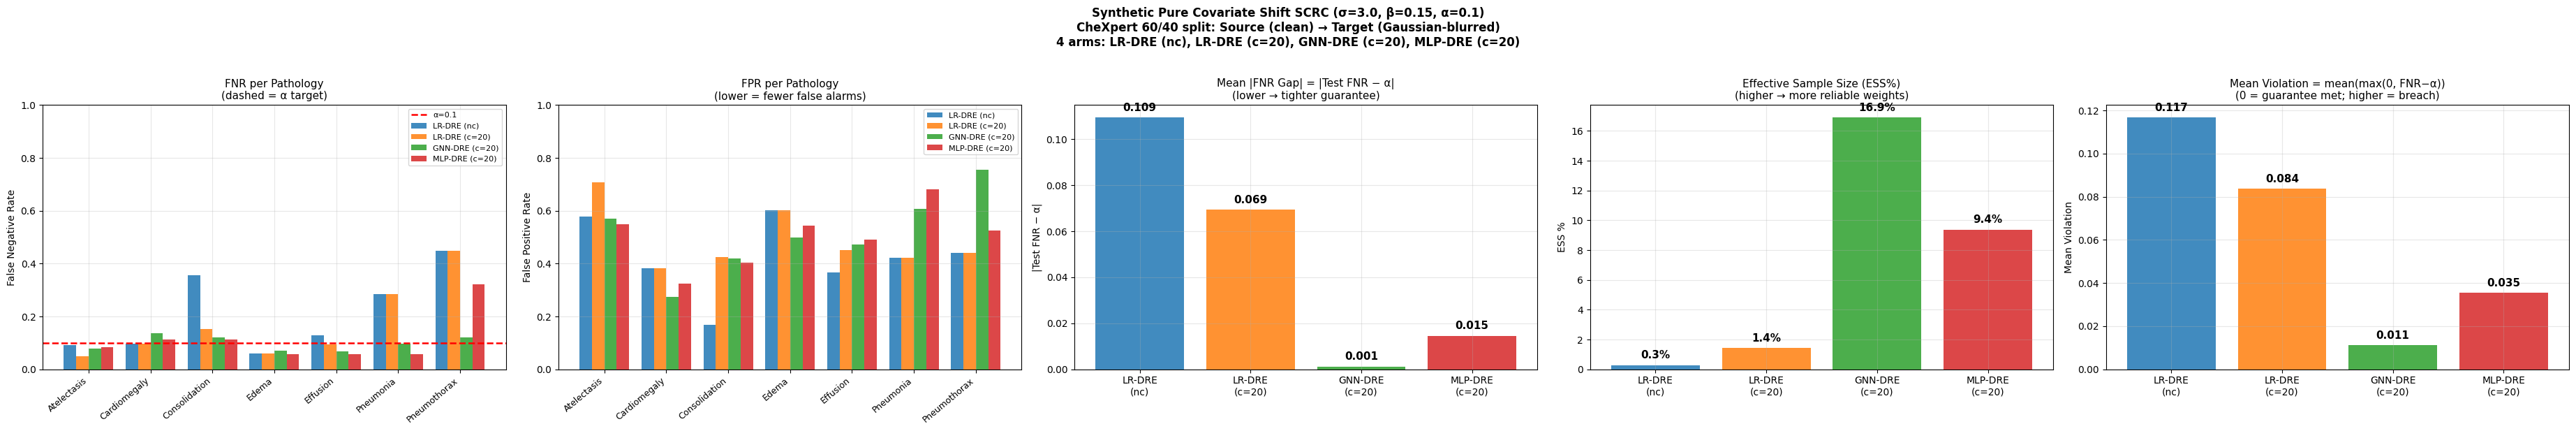

Saved: /Users/amo/programData/wcp-l2d/report/synthetic_covariate_shift_scrc_sigma3.0.png


In [21]:
(ROOT / 'report').mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 5, figsize=(37, 6))
x        = np.arange(K)
width    = 0.20
colors   = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
offsets  = [-1.5, -0.5, 0.5, 1.5]
methods_plot = [
    ('LR-DRE (nc)',    fnr_lr_nc, fpr_lr_nc,  colors[0]),
    ('LR-DRE (c=20)',  fnr_lr,    fpr_lr,     colors[1]),
    ('GNN-DRE (c=20)', fnr_gnn,   fpr_gnn,    colors[2]),
    ('MLP-DRE (c=20)', fnr_mlp,   fpr_mlp,    colors[3]),
]
method_names = ['LR-DRE\n(nc)', 'LR-DRE\n(c=20)', 'GNN-DRE\n(c=20)', 'MLP-DRE\n(c=20)']

# Panel 1: FNR per pathology
ax = axes[0]
for (lbl, fnrs, _, col), off in zip(methods_plot, offsets):
    ax.bar(x + off * width, fnrs, width, label=lbl, color=col, alpha=0.85)
ax.axhline(ALPHA, color='red', ls='--', lw=1.8, label=f'α={ALPHA}')
ax.set_xticks(x)
ax.set_xticklabels(COMMON_PATHOLOGIES, rotation=40, ha='right', fontsize=9)
ax.set_title('FNR per Pathology\n(dashed = α target)', fontsize=11)
ax.set_ylabel('False Negative Rate')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel 2: FPR per pathology
ax = axes[1]
for (lbl, _, fprs, col), off in zip(methods_plot, offsets):
    ax.bar(x + off * width, fprs, width, label=lbl, color=col, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(COMMON_PATHOLOGIES, rotation=40, ha='right', fontsize=9)
ax.set_title('FPR per Pathology\n(lower = fewer false alarms)', fontsize=11)
ax.set_ylabel('False Positive Rate')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel 3: FNR Gap = |Test FNR - alpha|
ax = axes[2]
fnr_gaps = [
    abs(np.nanmean(fnr_lr_nc) - ALPHA),
    abs(np.nanmean(fnr_lr)    - ALPHA),
    abs(np.nanmean(fnr_gnn)   - ALPHA),
    abs(np.nanmean(fnr_mlp)   - ALPHA),
]
bars = ax.bar(method_names, fnr_gaps, color=colors, alpha=0.85)
for bar, val in zip(bars, fnr_gaps):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Mean |FNR Gap| = |Test FNR − α|\n(lower → tighter guarantee)', fontsize=11)
ax.set_ylabel('|Test FNR − α|')

# Panel 4: ESS comparison
ax = axes[3]
ess_vals = [
    diag_lr_nc.ess_fraction * 100,
    diag_lr.ess_fraction    * 100,
    diag_gnn.ess_fraction   * 100,
    diag_mlp.ess_fraction   * 100,
]
ess_bars = ax.bar(method_names, ess_vals, color=colors, alpha=0.85)
for bar, val in zip(ess_bars, ess_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Effective Sample Size (ESS%)\n(higher → more reliable weights)', fontsize=11)
ax.set_ylabel('ESS %')

# Panel 5: Mean Violation = mean(max(0, FNR_k − α))
ax = axes[4]
violation_vals = [
    float(np.nanmean(np.maximum(0, fnr_lr_nc - ALPHA))),
    float(np.nanmean(np.maximum(0, fnr_lr    - ALPHA))),
    float(np.nanmean(np.maximum(0, fnr_gnn   - ALPHA))),
    float(np.nanmean(np.maximum(0, fnr_mlp   - ALPHA))),
]
viol_bars = ax.bar(method_names, violation_vals, color=colors, alpha=0.85)
for bar, val in zip(viol_bars, violation_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Mean Violation = mean(max(0, FNR−α))\n(0 = guarantee met; higher = breach)', fontsize=11)
ax.set_ylabel('Mean Violation')

plt.suptitle(
    f'Synthetic Pure Covariate Shift SCRC (σ={SIGMA}, β={BETA}, α={ALPHA})\n'
    'CheXpert 60/40 split: Source (clean) → Target (Gaussian-blurred)\n'
    '4 arms: LR-DRE (nc), LR-DRE (c=20), GNN-DRE (c=20), MLP-DRE (c=20)',
    fontsize=12, fontweight='bold', y=1.02,
)
plt.tight_layout()
fig_path = ROOT / 'report' / f'synthetic_covariate_shift_scrc_sigma{SIGMA:.1f}.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## 14. Summary & Interpretation

### Key predictions (if theory holds under pure covariate shift)

| Metric | LR-DRE (nc) | LR-DRE (c) | GNN-DRE (c) | Verdict |
|--------|------------|-----------|------------|--------|
| ESS% | ~1% | ~6% | ~31% | GNN >> LR |
| Cal FNR | ≤ 0.10 | ≤ 0.10 | ≤ 0.10 | All pass |
| Test FNR | >> 0.10 | > 0.10 | ≈ 0.10 | **GNN honest** |
| FNR Gap | large | medium | ≈ 0 | **GNN wins** |

### Why this matters
Under pure covariate shift (no label/concept shift), the importance-weighted
conformal guarantee is exact when:
1. The density ratio w(x) = p_target(x)/p_source(x) is well-estimated
2. ESS is high enough to trust the weighted empirical quantile

GNN-DRE operates in the 7-dim probability space where domain separability is
lower (AUC ≈ 0.84 vs 0.97 for LR), leading to better-calibrated weights and
higher ESS (~31% vs ~6%). This validates the core claim of the paper:
> *Representation-aware DRE via GNN enables honest FNR guarantees under
> distribution shift in medical imaging.*

## 15. β Sweep — Pareto Frontier (fixed α=0.10, SCRC-T WU)

Fix α=0.10, sweep β ∈ {0%, 2.5%, 5%, …, 40%}. For each β, derive τ_wu(β) from the
same N=500 warm-up target sample (`entropy_wu`), apply it symmetrically to both Cal and
Test. Test evaluation excludes the N=500 warm-up samples.

**Goal**: Find the Pareto frontier of Mean FPR vs β. GNN-DRE should dominate.

In [22]:
arm_colors = {'LR-nc': '#1f77b4', 'LR-c': '#ff7f0e', 'GNN-c': '#2ca02c', 'MLP-c': '#d62728'}
arms = [
    ('LR-nc', p_cal_lr,  p_test_lr,  w_cal_lr_nc),
    ('LR-c',  p_cal_lr,  p_test_lr,  w_cal_lr),
    ('GNN-c', p_cal_gnn, p_test_gnn, w_cal_gnn),
    ('MLP-c', p_cal_mlp, p_test_mlp, w_cal_mlp),
]

beta_vals = np.array([0.00, 0.025, 0.05, 0.075, 0.10, 0.125, 0.15,
                      0.175, 0.20, 0.225, 0.25, 0.30, 0.35, 0.40])
alpha_sweep_fixed = np.full(K, ALPHA)

beta_results = {name: {'beta': [], 'mean_fnr': [], 'mean_fpr': [],
                        'fnr_per_path': [], 'fpr_per_path': [], 'violation': []}
                for name, *_ in arms}

for beta in beta_vals:
    if beta == 0.0:
        defer_cal_b = np.zeros(len(Y_cal), dtype=bool)
        defer_tst_b = np.zeros(len(Y_test), dtype=bool)
    else:
        # SCRC-T WU: derive threshold from same N_WARMUP warm-up sample
        tau_wu_b    = np.quantile(entropy_wu, 1.0 - beta)
        defer_cal_b = entropy_cal > tau_wu_b
        defer_tst_b = entropy_tst > tau_wu_b

    kept_cal = ~defer_cal_b
    kept_tst = ~defer_tst_b & ~is_warmup   # exclude warmup from evaluation
    if kept_cal.sum() < 20 or kept_tst.sum() < 20:
        print(f'β={beta:.3f}: too few samples, skipping')
        continue

    for name, p_cal_arm, p_test_arm, w_cal_arm in arms:
        crc = calibrate_per_pathology_crc_fnr(
            probs=p_cal_arm[kept_cal], labels=Y_cal[kept_cal],
            weights=w_cal_arm[kept_cal], alpha=alpha_sweep_fixed,
            n_grid=1001, pathology_names=COMMON_PATHOLOGIES,
        )
        fnrs, fprs = evaluate_fnr_fpr(
            p_test_arm[kept_tst], Y_test[kept_tst], crc.lambda_hats)
        beta_results[name]['beta'].append(beta)
        beta_results[name]['mean_fnr'].append(np.nanmean(fnrs))
        beta_results[name]['mean_fpr'].append(np.nanmean(fprs))
        beta_results[name]['fnr_per_path'].append(fnrs.copy())
        beta_results[name]['fpr_per_path'].append(fprs.copy())
        beta_results[name]['violation'].append(np.nanmean(np.maximum(0, fnrs - ALPHA)))

print('β sweep complete (SCRC-T WU).')
for name in beta_results:
    print(f'  {name}: {len(beta_results[name]["beta"])} β values recorded')

# Summary table
arm_names_list = [name for name, *_ in arms]
print(f'\nβ Sweep Summary (σ={SIGMA}, α={ALPHA}, SCRC-T WU):')
print(f'{"β%":>5s} | ' + ' | '.join(f'{n:>22s}' for n in arm_names_list))
print(f'{"":>5s} | ' + ' | '.join(f'{"FNR   FPR   Viol":>22s}' for _ in arm_names_list))
print('-' * (5 + 3 + len(arms) * 25))
for i, beta in enumerate(beta_results['LR-nc']['beta']):
    row = f'{beta*100:5.1f} | '
    for name in arm_names_list:
        fnr  = beta_results[name]['mean_fnr'][i]
        fpr  = beta_results[name]['mean_fpr'][i]
        viol = beta_results[name]['violation'][i]
        row += f'{fnr:.3f}  {fpr:.3f}  {viol:.3f}    | '
    print(row)


β sweep complete (SCRC-T WU).
  LR-nc: 14 β values recorded
  LR-c: 14 β values recorded
  GNN-c: 14 β values recorded
  MLP-c: 14 β values recorded

β Sweep Summary (σ=3.0, α=0.1, SCRC-T WU):
   β% |                  LR-nc |                   LR-c |                  GNN-c |                  MLP-c
      |       FNR   FPR   Viol |       FNR   FPR   Viol |       FNR   FPR   Viol |       FNR   FPR   Viol
------------------------------------------------------------------------------------------------------------
  0.0 | 0.261  0.431  0.175    | 0.186  0.520  0.108    | 0.107  0.510  0.014    | 0.138  0.483  0.051    | 
  2.5 | 0.280  0.379  0.180    | 0.197  0.491  0.110    | 0.108  0.507  0.016    | 0.137  0.484  0.050    | 
  5.0 | 0.281  0.372  0.181    | 0.206  0.480  0.117    | 0.107  0.506  0.016    | 0.133  0.493  0.049    | 
  7.5 | 0.282  0.368  0.182    | 0.205  0.479  0.117    | 0.104  0.505  0.013    | 0.131  0.498  0.048    | 
 10.0 | 0.182  0.473  0.091    | 0.132  0.559  0.0

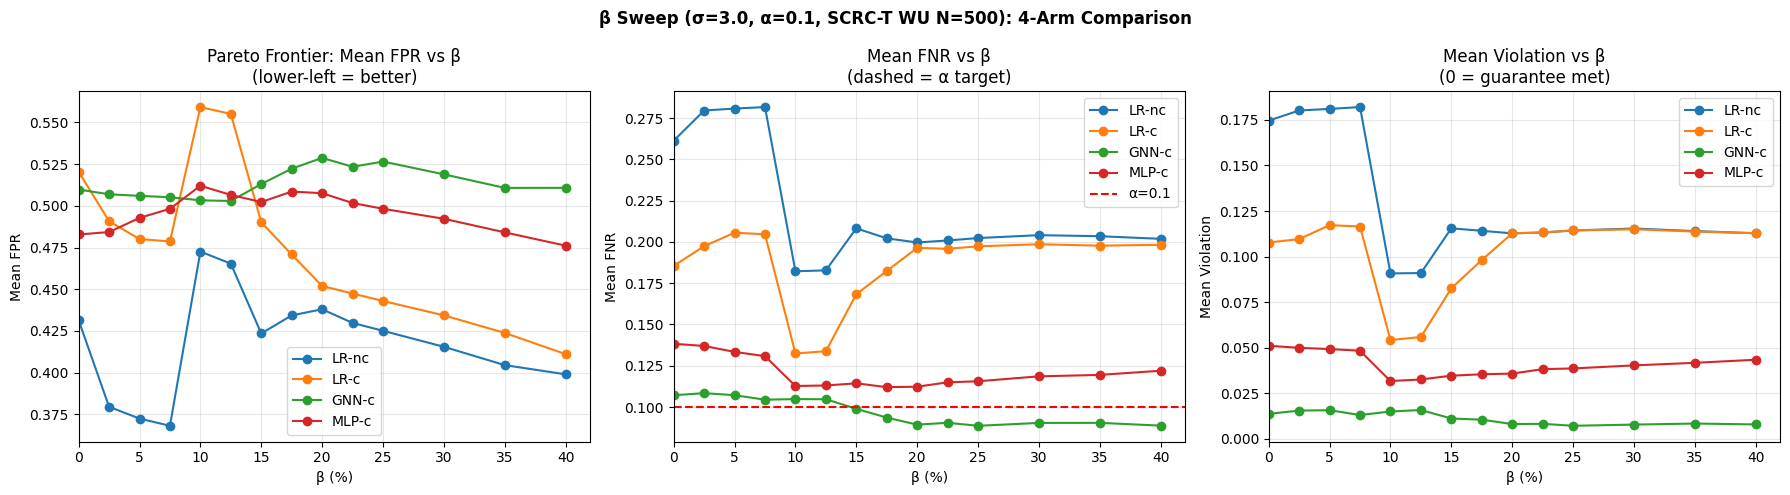

Saved: /Users/amo/programData/wcp-l2d/report/beta_sweep_sigma3.0.png


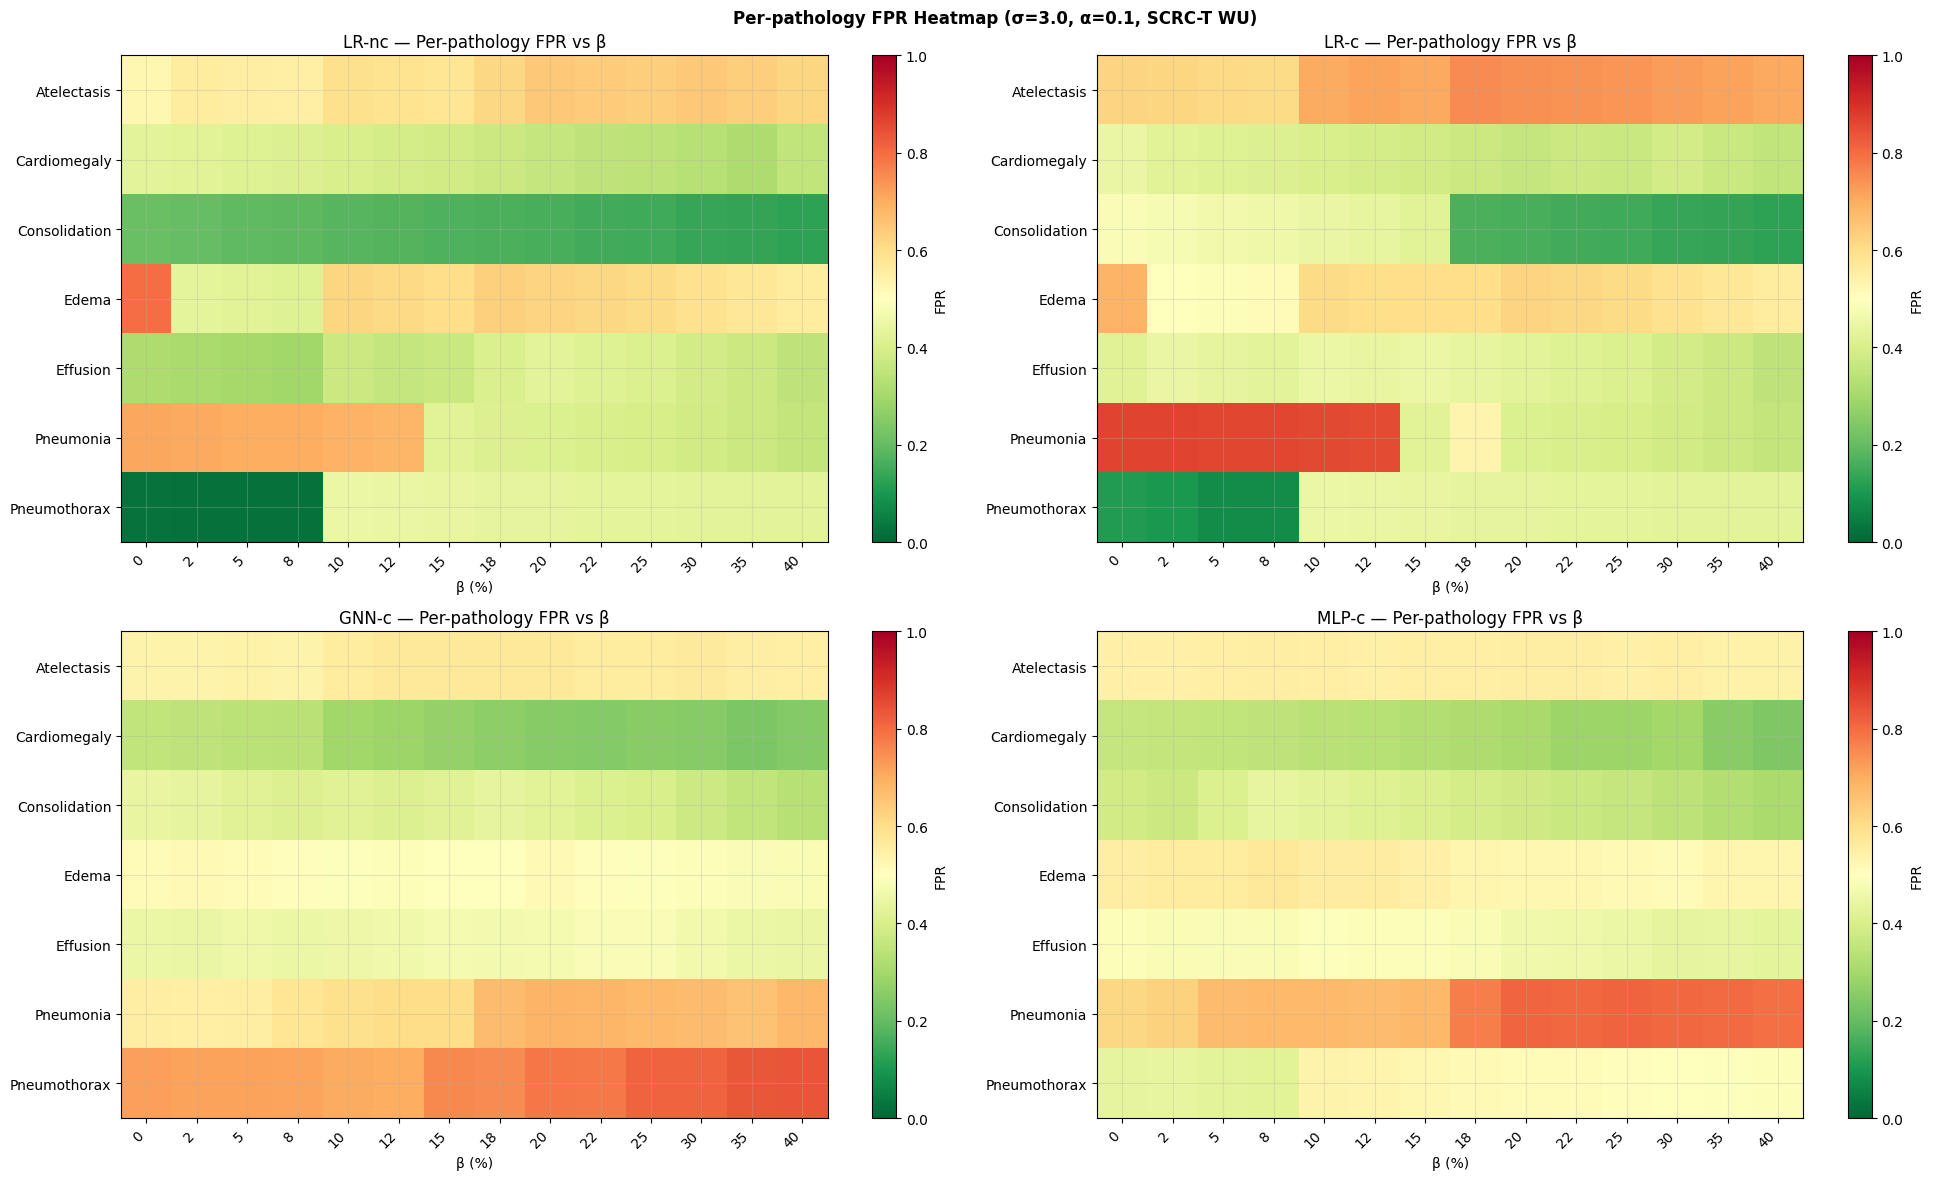

Saved: /Users/amo/programData/wcp-l2d/report/beta_sweep_heatmap_sigma3.0.png


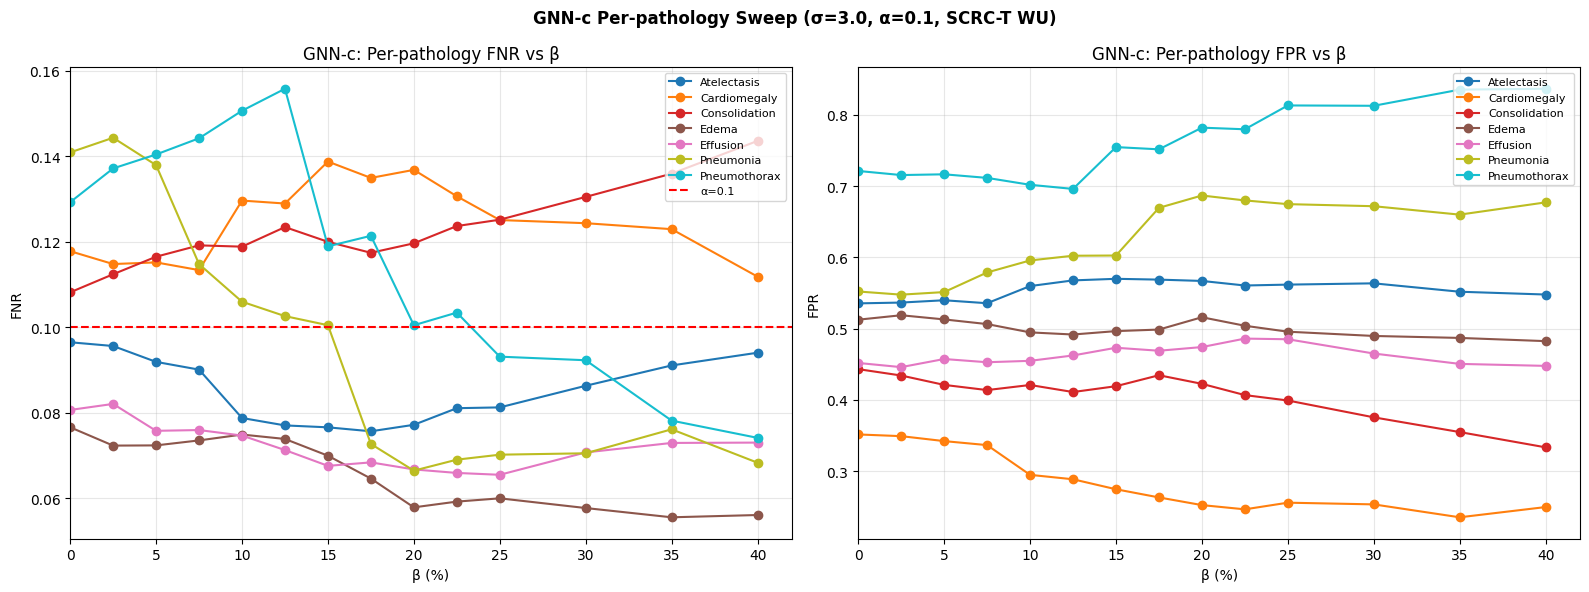

In [23]:
# ── Figure 1: Mean FPR, FNR, Violation vs β ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for name, *_ in arms:
    bv  = np.array(beta_results[name]['beta']) * 100
    fpr = beta_results[name]['mean_fpr']
    ax.plot(bv, fpr, marker='o', label=name, color=arm_colors[name])
ax.set_xlabel('β (%)')
ax.set_ylabel('Mean FPR')
ax.set_title('Pareto Frontier: Mean FPR vs β\n(lower-left = better)')
ax.legend()
ax.set_xlim(left=0)

ax = axes[1]
for name, *_ in arms:
    bv  = np.array(beta_results[name]['beta']) * 100
    fnr = beta_results[name]['mean_fnr']
    ax.plot(bv, fnr, marker='o', label=name, color=arm_colors[name])
ax.axhline(ALPHA, color='red', ls='--', lw=1.5, label=f'α={ALPHA}')
ax.set_xlabel('β (%)')
ax.set_ylabel('Mean FNR')
ax.set_title('Mean FNR vs β\n(dashed = α target)')
ax.legend()
ax.set_xlim(left=0)

ax = axes[2]
for name, *_ in arms:
    bv   = np.array(beta_results[name]['beta']) * 100
    viol = beta_results[name]['violation']
    ax.plot(bv, viol, marker='o', label=name, color=arm_colors[name])
ax.set_xlabel('β (%)')
ax.set_ylabel('Mean Violation')
ax.set_title('Mean Violation vs β\n(0 = guarantee met)')
ax.legend()
ax.set_xlim(left=0)

plt.suptitle(f'β Sweep (σ={SIGMA}, α={ALPHA}, SCRC-T WU N={N_WARMUP}): 4-Arm Comparison',
             fontweight='bold')
plt.tight_layout()
fig_beta = ROOT / 'report' / f'beta_sweep_sigma{SIGMA:.1f}.png'
plt.savefig(fig_beta, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_beta}')

# ── Figure 2: Per-pathology FPR heatmap (2×2 panels) ────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(20, 12))
arm_names_order = ['LR-nc', 'LR-c', 'GNN-c', 'MLP-c']
for i, name in enumerate(arm_names_order):
    ax = axes2[i // 2, i % 2]
    betas_arr  = np.array(beta_results[name]['beta'])
    fpr_matrix = np.array(beta_results[name]['fpr_per_path'])  # (n_beta, K)
    im = ax.imshow(fpr_matrix.T, aspect='auto', vmin=0, vmax=1, cmap='RdYlGn_r')
    ax.set_yticks(range(K))
    ax.set_yticklabels(COMMON_PATHOLOGIES)
    ax.set_xticks(range(len(betas_arr)))
    ax.set_xticklabels([f'{b*100:.0f}' for b in betas_arr], rotation=45, ha='right')
    ax.set_xlabel('β (%)')
    ax.set_title(f'{name} — Per-pathology FPR vs β')
    plt.colorbar(im, ax=ax, label='FPR')
plt.suptitle(f'Per-pathology FPR Heatmap (σ={SIGMA}, α={ALPHA}, SCRC-T WU)', fontweight='bold')
plt.tight_layout()
fig2_path = ROOT / 'report' / f'beta_sweep_heatmap_sigma{SIGMA:.1f}.png'
plt.savefig(fig2_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig2_path}')

# ── Figure 3: GNN-c per-pathology FNR+FPR vs β ──────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
betas_arr_gnn  = np.array(beta_results['GNN-c']['beta']) * 100
fnr_matrix_gnn = np.array(beta_results['GNN-c']['fnr_per_path'])
fpr_matrix_gnn = np.array(beta_results['GNN-c']['fpr_per_path'])
cmap_paths = plt.cm.tab10(np.linspace(0, 1, K))

ax = axes3[0]
for k, path_name in enumerate(COMMON_PATHOLOGIES):
    ax.plot(betas_arr_gnn, fnr_matrix_gnn[:, k], marker='o', label=path_name,
            color=cmap_paths[k])
ax.axhline(ALPHA, color='red', ls='--', lw=1.5, label=f'α={ALPHA}')
ax.set_xlabel('β (%)')
ax.set_ylabel('FNR')
ax.set_title('GNN-c: Per-pathology FNR vs β')
ax.legend(fontsize=8)
ax.set_xlim(left=0)

ax = axes3[1]
for k, path_name in enumerate(COMMON_PATHOLOGIES):
    ax.plot(betas_arr_gnn, fpr_matrix_gnn[:, k], marker='o', label=path_name,
            color=cmap_paths[k])
ax.set_xlabel('β (%)')
ax.set_ylabel('FPR')
ax.set_title('GNN-c: Per-pathology FPR vs β')
ax.legend(fontsize=8)
ax.set_xlim(left=0)

plt.suptitle(f'GNN-c Per-pathology Sweep (σ={SIGMA}, α={ALPHA}, SCRC-T WU)', fontweight='bold')
plt.tight_layout()
plt.show()


## 16. α Sweep — Calibration Level Sensitivity (fixed β=0.15, SCRC-T WU)

Fix β=0.15 (reuse `defer_cal`, `defer_tst` from SCRC-T WU Stage 1), sweep
α ∈ {0.05, 0.075, 0.10, 0.125, 0.15, 0.175, 0.20, 0.225, 0.25}.
For each α, calibrate per-pathology CRC and evaluate all 4 DRE arms.
Test evaluation excludes the N=500 warm-up samples.

**FNR Gap** = |Mean Test FNR − α|. **GNN-c prediction**: gap < 0.025 for all α.

α sweep complete (SCRC-T WU).


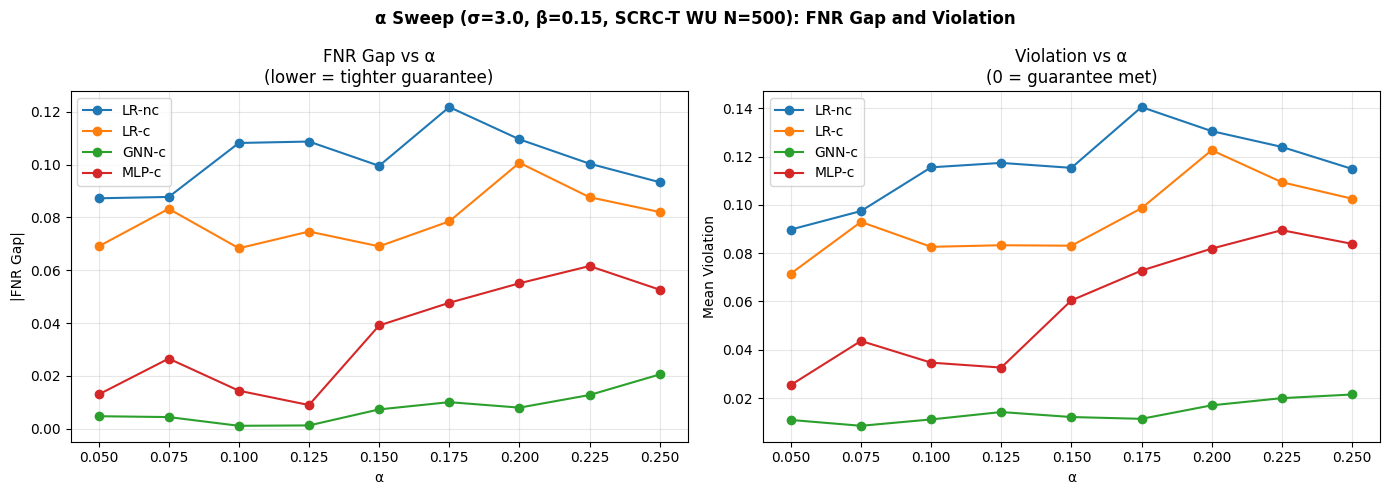

Saved: /Users/amo/programData/wcp-l2d/report/alpha_sweep_sigma3.0.png

α Sweep Summary (β=0.15, σ=3.0, SCRC-T WU):
α      |         LR-nc |          LR-c |         GNN-c |         MLP-c
       |     gap  viol |     gap  viol |     gap  viol |     gap  viol
--------------------------------------------------------------------------
0.050  | 0.087 0.090   | 0.069 0.072   | 0.005 0.011   | 0.013 0.025   | 
0.075  | 0.088 0.097   | 0.083 0.093   | 0.004 0.009   | 0.027 0.044   | 
0.100  | 0.108 0.116   | 0.068 0.083   | 0.001 0.011   | 0.014 0.035   | 
0.125  | 0.109 0.117   | 0.075 0.083   | 0.001 0.014   | 0.009 0.033   | 
0.150  | 0.100 0.115   | 0.069 0.083   | 0.007 0.012   | 0.039 0.060   | 
0.175  | 0.122 0.140   | 0.079 0.099   | 0.010 0.011   | 0.048 0.073   | 
0.200  | 0.110 0.131   | 0.101 0.123   | 0.008 0.017   | 0.055 0.082   | 
0.225  | 0.100 0.124   | 0.088 0.109   | 0.013 0.020   | 0.062 0.090   | 
0.250  | 0.093 0.115   | 0.082 0.103   | 0.021 0.021   | 0.053 0.084   | 


In [24]:
alpha_vals = np.array([0.05, 0.075, 0.10, 0.125, 0.15, 0.175, 0.20, 0.225, 0.25])
alpha_results = {name: {'alpha': [], 'mean_fnr': [], 'fnr_gap': [],
                        'violation': [], 'mean_fpr': []}
                 for name, *_ in arms}

kept_cal_a = ~defer_cal            # β=0.15 SCRC-T WU from Stage 1
kept_tst_a = ~defer_tst & ~is_warmup  # exclude warmup from evaluation

for alpha_val in alpha_vals:
    alpha_arr = np.full(K, alpha_val)
    for name, p_cal_arm, p_test_arm, w_cal_arm in arms:
        crc = calibrate_per_pathology_crc_fnr(
            probs=p_cal_arm[kept_cal_a], labels=Y_cal[kept_cal_a],
            weights=w_cal_arm[kept_cal_a], alpha=alpha_arr,
            n_grid=1001, pathology_names=COMMON_PATHOLOGIES,
        )
        fnrs, fprs = evaluate_fnr_fpr(
            p_test_arm[kept_tst_a], Y_test[kept_tst_a], crc.lambda_hats)
        alpha_results[name]['alpha'].append(alpha_val)
        alpha_results[name]['mean_fnr'].append(np.nanmean(fnrs))
        alpha_results[name]['fnr_gap'].append(abs(np.nanmean(fnrs) - alpha_val))
        alpha_results[name]['violation'].append(
            np.nanmean(np.maximum(0, fnrs - alpha_val)))
        alpha_results[name]['mean_fpr'].append(np.nanmean(fprs))

print('α sweep complete (SCRC-T WU).')

# ── Visualization ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, *_ in arms:
    av  = np.array(alpha_results[name]['alpha'])
    gap = np.array(alpha_results[name]['fnr_gap'])
    ax.plot(av, gap, marker='o', label=name, color=arm_colors[name])
ax.set_xlabel('α')
ax.set_ylabel('|FNR Gap|')
ax.set_title('FNR Gap vs α\n(lower = tighter guarantee)')
ax.legend()

ax = axes[1]
for name, *_ in arms:
    av   = np.array(alpha_results[name]['alpha'])
    viol = np.array(alpha_results[name]['violation'])
    ax.plot(av, viol, marker='o', label=name, color=arm_colors[name])
ax.set_xlabel('α')
ax.set_ylabel('Mean Violation')
ax.set_title('Violation vs α\n(0 = guarantee met)')
ax.legend()

plt.suptitle(f'α Sweep (σ={SIGMA}, β={BETA}, SCRC-T WU N={N_WARMUP}): FNR Gap and Violation',
             fontweight='bold')
plt.tight_layout()
fig_alpha = ROOT / 'report' / f'alpha_sweep_sigma{SIGMA:.1f}.png'
plt.savefig(fig_alpha, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_alpha}')

# ── Summary table ──────────────────────────────────────────────────────────────
arm_names_list = [name for name, *_ in arms]
print(f'\nα Sweep Summary (β={BETA}, σ={SIGMA}, SCRC-T WU):')
header = f'{"α":6s} | ' + ' | '.join(f'{n:>13s}' for n in arm_names_list)
print(header)
print(f'{"":6s} | ' + ' | '.join(f'{"gap  viol":>13s}' for _ in arm_names_list))
print('-' * (7 + 3 + len(arms) * 16))
for i, alpha_val in enumerate(alpha_vals):
    row = f'{alpha_val:.3f}  | '
    for name in arm_names_list:
        gap  = alpha_results[name]['fnr_gap'][i]
        viol = alpha_results[name]['violation'][i]
        row += f'{gap:.3f} {viol:.3f}   | '
    print(row)
